# Library Book Data Analyzer
### PDS Micro Project

### Aim
To load, manipulate, analyze, search, filter, sort and visualize library book data using Pandas, NumPy, Matplotlib and Seaborn.

In [1]:
# ============================================================
# LIBRARY BOOK DATA ANALYZER
# PDS MICRO PROJECT
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# ------------------------------------------------------------
# FILE PATH AND LOAD DATASET
# ------------------------------------------------------------

file_path = "library_books.csv"

try:
    df = pd.read_csv(file_path)

    print("\n================================================")
    print("       LIBRARY BOOK DATA ANALYZER")
    print("================================================")
    print("\nDataset loaded successfully.")
    print("Total records:", len(df))
    print("Columns:", list(df.columns))

except FileNotFoundError:
    print("\nError: library_books.csv file not found.")

except Exception as e:
    print("\nError while loading dataset:", e)

finally:
    print("Dataset loading process completed.")



       LIBRARY BOOK DATA ANALYZER

Dataset loaded successfully.
Total records: 30
Columns: ['Book_ID', 'Book_Name', 'Author', 'Genre', 'Language', 'Publication_Year', 'Rating', 'Available_Copies', 'Price']
Dataset loading process completed.


### 1. Display All Books

In [3]:
def display_all_books():
    try:
        if df.empty:
            print("\nNo books available.")
            return

        print("\n================ ALL BOOKS ================\n")
        print(df.to_string(index=False))
        print("\nTotal Books:", len(df))

    except Exception as e:
        print("Error:", e)

    finally:
        print("\nDisplay operation completed.")


### 2. Add New Book

In [4]:
def add_book():
    global df

    try:
        print("\n================ ADD NEW BOOK ================\n")

        book_id = input("Enter Book ID: ").strip()
        if book_id == "":
            print("Book ID cannot be empty.")
            return

        if book_id in df["Book_ID"].astype(str).values:
            print("Book ID already exists.")
            return

        book_name = input("Enter Book Name: ").strip()
        if book_name == "":
            print("Book Name cannot be empty.")
            return

        author = input("Enter Author Name: ").strip()
        if author == "":
            print("Author name cannot be empty.")
            return

        genre = input("Enter Genre: ").strip()
        if genre == "":
            print("Genre cannot be empty.")
            return

        publication_year = int(input("Enter Publication Year: "))
        if publication_year < 1900 or publication_year > 2100:
            print("Enter a valid publication year.")
            return

        rating = float(input("Enter Rating (0-5): "))
        if rating < 0 or rating > 5:
            print("Rating must be between 0 and 5.")
            return

        available_copies = int(input("Enter Available Copies: "))
        if available_copies < 0:
            print("Available copies cannot be negative.")
            return

        price = float(input("Enter Price: "))
        if price < 0:
            print("Price cannot be negative.")
            return

        language = input("Enter Language: ").strip()
        if language == "":
            print("Language cannot be empty.")
            return

        new_book = pd.DataFrame({
            "Book_ID": [book_id],
            "Book_Name": [book_name],
            "Author": [author],
            "Genre": [genre],
            "Publication_Year": [publication_year],
            "Rating": [rating],
            "Available_Copies": [available_copies],
            "Price": [price],
            "Language": [language]
        })

        df = pd.concat([df, new_book], ignore_index=True)
        df.to_csv(file_path, index=False)

        print("\nBook added successfully!")
        print(new_book.to_string(index=False))

    except ValueError:
        print("\nInvalid input! Enter correct numeric values.")

    except Exception as e:
        print("\nError while adding book:", e)

    finally:
        print("\nAdd book operation completed.")


### 3. Search Book by ID

In [5]:
def search_by_id():
    try:
        book_id = input("\nEnter Book ID: ").strip()
        result = df[df["Book_ID"].astype(str) == book_id]

        if result.empty:
            print("\nNo book found with this Book ID.")
        else:
            print("\n================ BOOK DETAILS ================\n")
            print(result.to_string(index=False))

    except Exception as e:
        print("\nError:", e)

    finally:
        print("\nSearch operation completed.")


### 4. Search Book by Name

In [6]:
def search_by_name():
    try:
        name = input("\nEnter Book Name: ").strip()

        result = df[
            df["Book_Name"].astype(str).str.contains(name, case=False, na=False)
        ]

        if result.empty:
            print("\nNo book found.")
        else:
            print("\n================ SEARCH RESULT ================\n")
            print(result.to_string(index=False))
            print("\nBooks Found:", len(result))

    except Exception as e:
        print("\nError:", e)

    finally:
        print("\nBook name search completed.")


### 5. Search Books by Author

In [7]:
def books_by_author():
    try:
        author = input("\nEnter Author Name: ").strip()

        result = df[
            df["Author"].astype(str).str.lower() == author.lower()
        ]

        if result.empty:
            print("\nNo books found for this author.")
        else:
            print("\n============================================")
            print("Books written by:", author)
            print("============================================\n")
            print(result.to_string(index=False))
            print("\nTotal books by this author:", len(result))

    except Exception as e:
        print("\nError:", e)

    finally:
        print("\nAuthor search completed.")


### 6. Search Books by Genre

In [8]:
def books_by_genre():
    try:
        genre = input("\nEnter Genre: ").strip()

        result = df[
            df["Genre"].astype(str).str.lower() == genre.lower()
        ]

        if result.empty:
            print("\nNo books found in this genre.")
        else:
            print("\n================ GENRE BOOKS ================\n")
            print(result.to_string(index=False))
            print("\nTotal books in this genre:", len(result))

    except Exception as e:
        print("\nError:", e)

    finally:
        print("\nGenre search completed.")


### 7. Search Books by Language

In [9]:
def books_by_language():
    try:
        language = input("\nEnter Language: ").strip()

        result = df[
            df["Language"].astype(str).str.lower() == language.lower()
        ]

        if result.empty:
            print("\nNo books found for this language.")
        else:
            print("\n================ LANGUAGE BOOKS ================\n")
            print(result.to_string(index=False))
            print("\nTotal books:", len(result))

    except Exception as e:
        print("\nError:", e)

    finally:
        print("\nLanguage search completed.")


### 8. Update Book

In [10]:
def update_book():
    global df

    try:
        print("\n================ UPDATE BOOK ================\n")
        book_id = input("Enter Book ID to update: ").strip()

        index_list = df.index[
            df["Book_ID"].astype(str) == book_id
        ].tolist()

        if len(index_list) == 0:
            print("\nBook not found.")
            return

        index = index_list[0]

        print("\nCurrent Book Details:")
        print(df.loc[[index]].to_string(index=False))

        print("\nEnter new details.")
        book_name = input("Enter new Book Name: ").strip()
        author = input("Enter new Author: ").strip()
        genre = input("Enter new Genre: ").strip()
        publication_year = int(input("Enter new Publication Year: "))
        rating = float(input("Enter new Rating (0-5): "))
        available_copies = int(input("Enter new Available Copies: "))
        price = float(input("Enter new Price: "))
        language = input("Enter new Language: ").strip()

        if rating < 0 or rating > 5:
            print("Rating must be between 0 and 5.")
            return
        if available_copies < 0:
            print("Available copies cannot be negative.")
            return
        if price < 0:
            print("Price cannot be negative.")
            return

        df.loc[index, "Book_Name"] = book_name
        df.loc[index, "Author"] = author
        df.loc[index, "Genre"] = genre
        df.loc[index, "Publication_Year"] = publication_year
        df.loc[index, "Rating"] = rating
        df.loc[index, "Available_Copies"] = available_copies
        df.loc[index, "Price"] = price
        df.loc[index, "Language"] = language

        df.to_csv(file_path, index=False)

        print("\nBook updated successfully!")
        print(df.loc[[index]].to_string(index=False))

    except ValueError:
        print("\nInvalid input! Please enter correct numeric values.")

    except Exception as e:
        print("\nError while updating:", e)

    finally:
        print("\nUpdate operation completed.")


### 9. Delete Book

In [11]:
def delete_book():
    global df

    try:
        print("\n================ DELETE BOOK ================\n")
        book_id = input("Enter Book ID to delete: ").strip()

        result = df[df["Book_ID"].astype(str) == book_id]

        if result.empty:
            print("\nBook not found.")
            return

        print("\nBook to be deleted:")
        print(result.to_string(index=False))

        confirm = input(
            "\nAre you sure you want to delete this book? (y/n): "
        ).lower()

        if confirm == "y":
            df = df[df["Book_ID"].astype(str) != book_id]
            df.to_csv(file_path, index=False)
            print("\nBook deleted successfully.")
        else:
            print("\nDelete operation cancelled.")

    except Exception as e:
        print("\nError while deleting:", e)

    finally:
        print("\nDelete operation completed.")


### 10. Library Statistics

In [12]:
def library_statistics():
    try:
        print("\n================================================")
        print("              LIBRARY STATISTICS")
        print("================================================")

        total_books = len(df)
        total_authors = df["Author"].nunique()
        total_genres = df["Genre"].nunique()
        average_rating = df["Rating"].mean()
        total_copies = df["Available_Copies"].sum()
        average_price = df["Price"].mean()

        print("\nTotal Books:", total_books)
        print("Total Authors:", total_authors)
        print("Total Genres:", total_genres)
        print("Average Rating:", round(average_rating, 2))
        print("Total Available Copies:", total_copies)
        print("Average Book Price:", round(average_price, 2))

        print("\nGenre Count:")
        print(df["Genre"].value_counts())

        print("\nAuthor Count:")
        print(df["Author"].value_counts())

    except Exception as e:
        print("\nError:", e)

    finally:
        print("\nStatistics operation completed.")


### 11. Rating and Price Analysis

In [13]:
def rating_price_analysis():
    try:
        print("\n================================================")
        print("           RATING AND PRICE ANALYSIS")
        print("================================================")

        highest_rating = df["Rating"].max()
        lowest_rating = df["Rating"].min()

        print("\nHighest Rating:", highest_rating)
        print("Lowest Rating:", lowest_rating)

        highest_rated = df[df["Rating"] == highest_rating]
        print("\nHighest Rated Book(s):")
        print(highest_rated[["Book_Name", "Author", "Rating"]].to_string(index=False))

        lowest_rated = df[df["Rating"] == lowest_rating]
        print("\nLowest Rated Book(s):")
        print(lowest_rated[["Book_Name", "Author", "Rating"]].to_string(index=False))

        expensive = df["Price"].max()
        cheapest = df["Price"].min()

        print("\nMost Expensive Price:", expensive)
        print("Cheapest Price:", cheapest)

        print("\nMost Expensive Book:")
        print(df[df["Price"] == expensive][["Book_Name", "Price"]].to_string(index=False))

        print("\nCheapest Book:")
        print(df[df["Price"] == cheapest][["Book_Name", "Price"]].to_string(index=False))

    except Exception as e:
        print("\nError:", e)

    finally:
        print("\nRating and price analysis completed.")


### 12. Advanced Analysis

In [14]:
def advanced_analysis():
    try:
        print("\n================================================")
        print("              ADVANCED ANALYSIS")
        print("================================================")

        print("\nAverage Rating by Genre:")
        genre_rating = df.groupby("Genre")["Rating"].mean().sort_values(ascending=False)
        print(genre_rating.round(2))

        print("\nAvailable Copies by Genre:")
        genre_copies = df.groupby("Genre")["Available_Copies"].sum().sort_values(ascending=False)
        print(genre_copies)

        print("\nPublication Year Count:")
        year_count = df["Publication_Year"].value_counts().sort_index()
        print(year_count)

        print("\nTop 10 Authors:")
        top_authors = df["Author"].value_counts().head(10)
        print(top_authors)

    except Exception as e:
        print("\nError:", e)

    finally:
        print("\nAdvanced analysis completed.")


### 13. NumPy Analysis

In [15]:
def numpy_analysis():
    try:
        print("\n================================================")
        print("                NUMPY ANALYSIS")
        print("================================================")

        ratings = np.array(df["Rating"])
        prices = np.array(df["Price"])

        print("\nRating Analysis using NumPy")
        print("Maximum Rating:", np.max(ratings))
        print("Minimum Rating:", np.min(ratings))
        print("Average Rating:", round(np.mean(ratings), 2))

        print("\nPrice Analysis using NumPy")
        print("Maximum Price:", np.max(prices))
        print("Minimum Price:", np.min(prices))
        print("Average Price:", round(np.mean(prices), 2))

    except Exception as e:
        print("\nError:", e)

    finally:
        print("\nNumPy analysis completed.")


### 14. Filter Books by Rating

In [16]:
def filter_by_rating():
    try:
        rating = float(input("\nEnter minimum rating: "))

        if rating < 0 or rating > 5:
            print("Rating must be between 0 and 5.")
            return

        result = df[df["Rating"] >= rating].sort_values(
            by="Rating", ascending=False
        )

        if result.empty:
            print("\nNo books found.")
        else:
            print("\nBooks with rating >= ", rating)
            print(result.to_string(index=False))
            print("\nTotal books:", len(result))

    except ValueError:
        print("\nPlease enter a valid number.")

    except Exception as e:
        print("\nError:", e)

    finally:
        print("\nRating filter operation completed.")


### 15. Sort Books

In [17]:
def sort_books():
    try:
        print("\n================ SORT BOOKS ================")
        print("1. Sort by Book Name")
        print("2. Sort by Rating")
        print("3. Sort by Price")
        print("4. Sort by Publication Year")
        print("5. Sort by Available Copies")

        choice = input("\nEnter your choice: ")

        columns = {
            "1": "Book_Name",
            "2": "Rating",
            "3": "Price",
            "4": "Publication_Year",
            "5": "Available_Copies"
        }

        if choice not in columns:
            print("\nInvalid choice.")
            return

        column = columns[choice]
        result = df.sort_values(by=column, ascending=True)

        print("\nBooks sorted by", column, ":\n")
        print(result.to_string(index=False))

    except Exception as e:
        print("\nError:", e)

    finally:
        print("\nSorting operation completed.")


### 16. Visualizations

In [18]:
def generate_visualizations():
    try:
        print("\nGenerating visualizations...")

        # 1. Genre Count
        genre_count = df["Genre"].value_counts()
        plt.figure(figsize=(10, 5))
        genre_count.plot(kind="bar")
        plt.title("Number of Books by Genre")
        plt.xlabel("Genre")
        plt.ylabel("Number of Books")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # 2. Publication Year
        year_count = df["Publication_Year"].value_counts().sort_index()
        plt.figure(figsize=(10, 5))
        plt.plot(year_count.index, year_count.values, marker="o")
        plt.title("Books by Publication Year")
        plt.xlabel("Publication Year")
        plt.ylabel("Number of Books")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # 3. Rating Distribution
        plt.figure(figsize=(8, 5))
        sns.histplot(df["Rating"], bins=10, kde=True)
        plt.title("Rating Distribution")
        plt.xlabel("Rating")
        plt.ylabel("Number of Books")
        plt.tight_layout()
        plt.show()

        # 4. Top 10 Authors
        top_authors = df["Author"].value_counts().head(10)
        plt.figure(figsize=(10, 5))
        top_authors.plot(kind="bar")
        plt.title("Top 10 Authors")
        plt.xlabel("Author")
        plt.ylabel("Number of Books")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # 5. Average Rating by Genre
        avg_rating = df.groupby("Genre")["Rating"].mean()
        plt.figure(figsize=(10, 5))
        avg_rating.plot(kind="bar")
        plt.title("Average Rating by Genre")
        plt.xlabel("Genre")
        plt.ylabel("Average Rating")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # 6. Available Copies by Genre
        copies = df.groupby("Genre")["Available_Copies"].sum()
        plt.figure(figsize=(10, 5))
        copies.plot(kind="bar")
        plt.title("Available Copies by Genre")
        plt.xlabel("Genre")
        plt.ylabel("Available Copies")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        print("\nAll visualizations generated successfully.")

    except Exception as e:
        print("\nError while generating visualization:", e)

    finally:
        print("\nVisualization operation completed.")


### 17. Dashboard

In [19]:
def generate_dashboard():
    try:
        print("\nGenerating dashboard...")

        total_books = len(df)
        average_rating = df["Rating"].mean()
        total_genres = df["Genre"].nunique()
        total_authors = df["Author"].nunique()

        genre_count = df["Genre"].value_counts()
        year_count = df["Publication_Year"].value_counts().sort_index()
        top_authors = df["Author"].value_counts().head(10)
        avg_rating = df.groupby("Genre")["Rating"].mean().sort_values(ascending=False)

        plt.figure(figsize=(15, 10))
        plt.suptitle(
            "LIBRARY BOOK DATA ANALYZER DASHBOARD",
            fontsize=20,
            fontweight="bold"
        )

        # Chart 1
        plt.subplot(2, 2, 1)
        genre_count.plot(kind="bar")
        plt.title("Books by Genre")
        plt.xlabel("Genre")
        plt.ylabel("Number of Books")
        plt.xticks(rotation=45)

        # Chart 2
        plt.subplot(2, 2, 2)
        plt.plot(year_count.index, year_count.values, marker="o")
        plt.title("Books by Publication Year")
        plt.xlabel("Year")
        plt.ylabel("Number of Books")

        # Chart 3
        plt.subplot(2, 2, 3)
        top_authors.plot(kind="bar")
        plt.title("Top 10 Authors")
        plt.xlabel("Author")
        plt.ylabel("Number of Books")
        plt.xticks(rotation=45)

        # Chart 4
        plt.subplot(2, 2, 4)
        avg_rating.plot(kind="bar")
        plt.title("Average Rating by Genre")
        plt.xlabel("Genre")
        plt.ylabel("Average Rating")
        plt.xticks(rotation=45)

        plt.figtext(
            0.02, 0.02,
            "Total Books: " + str(total_books)
            + "     |     Average Rating: " + str(round(average_rating, 2))
            + "     |     Total Genres: " + str(total_genres)
            + "     |     Total Authors: " + str(total_authors),
            fontsize=12
        )

        plt.tight_layout(rect=[0, 0.05, 1, 0.95])
        plt.savefig("library_dashboard.png", dpi=300)
        plt.show()

        print("\nDashboard saved as 'library_dashboard.png'")

    except Exception as e:
        print("\nError while creating dashboard:", e)

    finally:
        print("\nDashboard operation completed.")


### 18. Main Menu

In [20]:
def main_menu():
    while True:
        try:
            print("\n")
            print("================================================")
            print("       LIBRARY BOOK DATA ANALYZER")
            print("================================================")

            print("\n1.  Display All Books")
            print("2.  Add New Book")
            print("3.  Search Book by ID")
            print("4.  Search Book by Name")
            print("5.  Display Books by Author")
            print("6.  Display Books by Genre")
            print("7.  Display Books by Language")
            print("8.  Update Book")
            print("9.  Delete Book")
            print("10. Library Statistics")
            print("11. Rating and Price Analysis")
            print("12. Advanced Analysis")
            print("13. NumPy Analysis")
            print("14. Filter Books by Rating")
            print("15. Sort Books")
            print("16. Generate Visualizations")
            print("17. Generate Dashboard")
            print("18. Exit")

            choice = input("\nEnter your choice: ")

            if choice == "1":
                display_all_books()
            elif choice == "2":
                add_book()
            elif choice == "3":
                search_by_id()
            elif choice == "4":
                search_by_name()
            elif choice == "5":
                books_by_author()
            elif choice == "6":
                books_by_genre()
            elif choice == "7":
                books_by_language()
            elif choice == "8":
                update_book()
            elif choice == "9":
                delete_book()
            elif choice == "10":
                library_statistics()
            elif choice == "11":
                rating_price_analysis()
            elif choice == "12":
                advanced_analysis()
            elif choice == "13":
                numpy_analysis()
            elif choice == "14":
                filter_by_rating()
            elif choice == "15":
                sort_books()
            elif choice == "16":
                generate_visualizations()
            elif choice == "17":
                generate_dashboard()
            elif choice == "18":
                print("\nThank you for using Library Book Data Analyzer.")
                break
            else:
                print("\nInvalid choice!")
                print("Please enter a number from 1 to 18.")

        except KeyboardInterrupt:
            print("\n\nProgram interrupted by user.")
            break

        except Exception as e:
            print("\nUnexpected error:", e)

        finally:
            print("\n--------------------------------------------")


### 19. Run Menu

## Complete Practical Outputs
The following cells demonstrate every practical with sample inputs. Interactive `main_menu()` is intentionally not executed so the notebook runs completely and saves outputs.

### 20. Automatic Analysis Output

In [21]:
# This cell runs the non-interactive analyses and saves their outputs.
# The main_menu() above is interactive; use option 18 to exit.

print("================================================")
print("       AUTOMATIC LIBRARY ANALYSIS")
print("================================================")

print("\nDataset shape:", df.shape)
print("\nFirst 5 records:")
print(df.head().to_string(index=False))

print("\nLibrary Statistics:")
print("Total Books:", len(df))
print("Total Authors:", df["Author"].nunique())
print("Total Genres:", df["Genre"].nunique())
print("Average Rating:", round(df["Rating"].mean(), 2))
print("Total Available Copies:", int(df["Available_Copies"].sum()))
print("Average Book Price:", round(df["Price"].mean(), 2))

print("\nHighest Rated Books:")
highest = df[df["Rating"] == df["Rating"].max()]
print(highest[["Book_Name", "Author", "Rating"]].to_string(index=False))

print("\nMost Expensive Books:")
expensive = df[df["Price"] == df["Price"].max()]
print(expensive[["Book_Name", "Price"]].to_string(index=False))

print("\nAverage Rating by Genre:")
print(df.groupby("Genre")["Rating"].mean().round(2).sort_values(ascending=False))

print("\nTop 10 Authors:")
print(df["Author"].value_counts().head(10))

print("\nNumPy Analysis:")
ratings = np.array(df["Rating"])
prices = np.array(df["Price"])
print("Maximum Rating:", np.max(ratings))
print("Minimum Rating:", np.min(ratings))
print("Average Rating:", round(np.mean(ratings), 2))
print("Maximum Price:", np.max(prices))
print("Minimum Price:", np.min(prices))
print("Average Price:", round(np.mean(prices), 2))

print("\nAutomatic analysis completed successfully.")


       AUTOMATIC LIBRARY ANALYSIS

Dataset shape: (30, 9)

First 5 records:
 Book_ID             Book_Name              Author   Genre Language  Publication_Year  Rating  Available_Copies  Price
       1         The Alchemist        Paulo Coelho Fiction  English              1988     4.6                12    299
       2                  1984       George Orwell Fiction  English              1949     4.7                 8    350
       3 To Kill a Mockingbird          Harper Lee Fiction  English              1960     4.8                 6    420
       4      The Great Gatsby F. Scott Fitzgerald Classic  English              1925     4.4                10    280
       5   Pride and Prejudice         Jane Austen Romance  English              1813     4.7                 9    320

Library Statistics:
Total Books: 30
Total Authors: 30
Total Genres: 12
Average Rating: 4.62
Total Available Copies: 235
Average Book Price: 493.57

Highest Rated Books:
   Book_Name       Author  Rating
Harry 

### 1. Display All Books — Output

In [22]:
import builtins
_original_df = df.copy(deep=True)
def reset_demo_data():
    global df
    df = _original_df.copy(deep=True)
def run_with_inputs(func, values):
    it = iter(values)
    old = builtins.input
    builtins.input = lambda prompt='': (print(prompt, end=''), str(next(it)))[1]
    try:
        func()
    finally:
        builtins.input = old

reset_demo_data()
display_all_books()


================ ALL BOOKS ================

 Book_ID                 Book_Name                   Author      Genre Language  Publication_Year  Rating  Available_Copies  Price
       1             The Alchemist             Paulo Coelho    Fiction  English              1988     4.6                12    299
       2                      1984            George Orwell    Fiction  English              1949     4.7                 8    350
       3     To Kill a Mockingbird               Harper Lee    Fiction  English              1960     4.8                 6    420
       4          The Great Gatsby      F. Scott Fitzgerald    Classic  English              1925     4.4                10    280
       5       Pride and Prejudice              Jane Austen    Romance  English              1813     4.7                 9    320
       6              Harry Potter             J.K. Rowling    Fantasy  English              1997     4.9                15    550
       7                The Hobbit   

### 2. Add New Book — Output

In [23]:
import builtins
_original_df = df.copy(deep=True)
def reset_demo_data():
    global df
    df = _original_df.copy(deep=True)
def run_with_inputs(func, values):
    it = iter(values)
    old = builtins.input
    builtins.input = lambda prompt='': (print(prompt, end=''), str(next(it)))[1]
    try:
        func()
    finally:
        builtins.input = old

reset_demo_data()
run_with_inputs(add_book, ['31','The Alchemist Returns','Test Author','Fiction','2020','4.6','10','399','English'])


================ ADD NEW BOOK ================

Enter Book ID: Enter Book Name: Enter Author Name: Enter Genre: Enter Publication Year: Enter Rating (0-5): Enter Available Copies: Enter Price: Enter Language: 
Book added successfully!
Book_ID             Book_Name      Author   Genre  Publication_Year  Rating  Available_Copies  Price Language
     31 The Alchemist Returns Test Author Fiction              2020     4.6                10  399.0  English

Add book operation completed.


### 3. Search Book by ID — Output

In [24]:
import builtins
_original_df = df.copy(deep=True)
def reset_demo_data():
    global df
    df = _original_df.copy(deep=True)
def run_with_inputs(func, values):
    it = iter(values)
    old = builtins.input
    builtins.input = lambda prompt='': (print(prompt, end=''), str(next(it)))[1]
    try:
        func()
    finally:
        builtins.input = old

reset_demo_data()
run_with_inputs(search_by_id, ['10'])


Enter Book ID: 
================ BOOK DETAILS ================

Book_ID         Book_Name          Author   Genre Language  Publication_Year  Rating  Available_Copies  Price
     10 Rich Dad Poor Dad Robert Kiyosaki Finance  English              1997     4.6                13  450.0

Search operation completed.


### 4. Search Book by Name — Output

In [25]:
import builtins
_original_df = df.copy(deep=True)
def reset_demo_data():
    global df
    df = _original_df.copy(deep=True)
def run_with_inputs(func, values):
    it = iter(values)
    old = builtins.input
    builtins.input = lambda prompt='': (print(prompt, end=''), str(next(it)))[1]
    try:
        func()
    finally:
        builtins.input = old

reset_demo_data()
run_with_inputs(search_by_name, ['Python'])


Enter Book Name: 
================ SEARCH RESULT ================

Book_ID           Book_Name       Author      Genre Language  Publication_Year  Rating  Available_Copies  Price
     24 Python Crash Course Eric Matthes Technology  English              2016     4.8                 7  900.0

Books Found: 1

Book name search completed.


### 5. Search Books by Author — Output

In [26]:
import builtins
_original_df = df.copy(deep=True)
def reset_demo_data():
    global df
    df = _original_df.copy(deep=True)
def run_with_inputs(func, values):
    it = iter(values)
    old = builtins.input
    builtins.input = lambda prompt='': (print(prompt, end=''), str(next(it)))[1]
    try:
        func()
    finally:
        builtins.input = old

reset_demo_data()
run_with_inputs(books_by_author, ['George Orwell'])


Enter Author Name: 
Books written by: George Orwell

Book_ID Book_Name        Author   Genre Language  Publication_Year  Rating  Available_Copies  Price
      2      1984 George Orwell Fiction  English              1949     4.7                 8  350.0

Total books by this author: 1

Author search completed.


### 6. Search Books by Genre — Output

In [27]:
import builtins
_original_df = df.copy(deep=True)
def reset_demo_data():
    global df
    df = _original_df.copy(deep=True)
def run_with_inputs(func, values):
    it = iter(values)
    old = builtins.input
    builtins.input = lambda prompt='': (print(prompt, end=''), str(next(it)))[1]
    try:
        func()
    finally:
        builtins.input = old

reset_demo_data()
run_with_inputs(books_by_genre, ['Technology'])


Enter Genre: 
================ GENRE BOOKS ================

Book_ID                Book_Name           Author      Genre Language  Publication_Year  Rating  Available_Copies  Price
     23               Clean Code Robert C. Martin Technology  English              2008     4.5                 5  850.0
     24      Python Crash Course     Eric Matthes Technology  English              2016     4.8                 7  900.0
     25 The Pragmatic Programmer      Andrew Hunt Technology  English              1999     4.7                 4  950.0
     26    Data Science Handbook       Field Cady Technology  English              2010     4.4                 6  799.0

Total books in this genre: 4

Genre search completed.


### 7. Search Books by Language — Output

In [28]:
import builtins
_original_df = df.copy(deep=True)
def reset_demo_data():
    global df
    df = _original_df.copy(deep=True)
def run_with_inputs(func, values):
    it = iter(values)
    old = builtins.input
    builtins.input = lambda prompt='': (print(prompt, end=''), str(next(it)))[1]
    try:
        func()
    finally:
        builtins.input = old

reset_demo_data()
run_with_inputs(books_by_language, ['English'])


Enter Language: 
================ LANGUAGE BOOKS ================

Book_ID                 Book_Name                   Author      Genre Language  Publication_Year  Rating  Available_Copies  Price
      1             The Alchemist             Paulo Coelho    Fiction  English              1988     4.6                12  299.0
      2                      1984            George Orwell    Fiction  English              1949     4.7                 8  350.0
      3     To Kill a Mockingbird               Harper Lee    Fiction  English              1960     4.8                 6  420.0
      4          The Great Gatsby      F. Scott Fitzgerald    Classic  English              1925     4.4                10  280.0
      5       Pride and Prejudice              Jane Austen    Romance  English              1813     4.7                 9  320.0
      6              Harry Potter             J.K. Rowling    Fantasy  English              1997     4.9                15  550.0
      7               

### 8. Update Book — Output

In [29]:
import builtins
_original_df = df.copy(deep=True)
def reset_demo_data():
    global df
    df = _original_df.copy(deep=True)
def run_with_inputs(func, values):
    it = iter(values)
    old = builtins.input
    builtins.input = lambda prompt='': (print(prompt, end=''), str(next(it)))[1]
    try:
        func()
    finally:
        builtins.input = old

reset_demo_data()
run_with_inputs(update_book, ['1','The Alchemist Updated','Paulo Coelho','Fiction','1988','4.9','15','349','English'])


================ UPDATE BOOK ================

Enter Book ID to update: 
Current Book Details:
Book_ID     Book_Name       Author   Genre Language  Publication_Year  Rating  Available_Copies  Price
      1 The Alchemist Paulo Coelho Fiction  English              1988     4.6                12  299.0

Enter new details.
Enter new Book Name: Enter new Author: Enter new Genre: Enter new Publication Year: Enter new Rating (0-5): Enter new Available Copies: Enter new Price: Enter new Language: 
Book updated successfully!
Book_ID             Book_Name       Author   Genre Language  Publication_Year  Rating  Available_Copies  Price
      1 The Alchemist Updated Paulo Coelho Fiction  English              1988     4.9                15  349.0

Update operation completed.


### 9. Delete Book — Output

In [30]:
import builtins
_original_df = df.copy(deep=True)
def reset_demo_data():
    global df
    df = _original_df.copy(deep=True)
def run_with_inputs(func, values):
    it = iter(values)
    old = builtins.input
    builtins.input = lambda prompt='': (print(prompt, end=''), str(next(it)))[1]
    try:
        func()
    finally:
        builtins.input = old

reset_demo_data()
run_with_inputs(delete_book, ['30','y'])


================ DELETE BOOK ================

Enter Book ID to delete: 
Book to be deleted:
Book_ID       Book_Name        Author Genre Language  Publication_Year  Rating  Available_Copies  Price
     30 The White Tiger Aravind Adiga Drama  English              2008     4.4                 5  360.0

Are you sure you want to delete this book? (y/n): 
Book deleted successfully.

Delete operation completed.


### 10. Library Statistics — Output

In [31]:
import builtins
_original_df = df.copy(deep=True)
def reset_demo_data():
    global df
    df = _original_df.copy(deep=True)
def run_with_inputs(func, values):
    it = iter(values)
    old = builtins.input
    builtins.input = lambda prompt='': (print(prompt, end=''), str(next(it)))[1]
    try:
        func()
    finally:
        builtins.input = old

reset_demo_data()
library_statistics()


              LIBRARY STATISTICS

Total Books: 30
Total Authors: 30
Total Genres: 12
Average Rating: 4.64
Total Available Copies: 243
Average Book Price: 496.53

Genre Count:
Genre
Fiction       5
Self-Help     4
Technology    4
Classic       3
Thriller      2
Fantasy       2
Biography     2
Finance       2
Drama         2
Science       2
Romance       1
History       1
Name: count, dtype: int64

Author Count:
Author
Paulo Coelho                1
George Orwell               1
Harper Lee                  1
F. Scott Fitzgerald         1
Jane Austen                 1
J.K. Rowling                1
J.R.R. Tolkien              1
James Clear                 1
Hector Garcia               1
Robert Kiyosaki             1
Morgan Housel               1
A.P.J. Abdul Kalam          1
Mahatma Gandhi              1
Yuval Noah Harari           1
Stephen Hawking             1
Carl Sagan                  1
Alex Michaelides            1
Gillian Flynn               1
Khaled Hosseini             1
Markus Z

### 11. Rating and Price Analysis — Output

In [32]:
import builtins
_original_df = df.copy(deep=True)
def reset_demo_data():
    global df
    df = _original_df.copy(deep=True)
def run_with_inputs(func, values):
    it = iter(values)
    old = builtins.input
    builtins.input = lambda prompt='': (print(prompt, end=''), str(next(it)))[1]
    try:
        func()
    finally:
        builtins.input = old

reset_demo_data()
rating_price_analysis()


           RATING AND PRICE ANALYSIS

Highest Rating: 4.9
Lowest Rating: 4.3

Highest Rated Book(s):
            Book_Name       Author  Rating
The Alchemist Updated Paulo Coelho     4.9
         Harry Potter J.K. Rowling     4.9

Lowest Rated Book(s):
  Book_Name Author  Rating
The Odyssey  Homer     4.3

Most Expensive Price: 950.0
Cheapest Price: 250.0

Most Expensive Book:
               Book_Name  Price
The Pragmatic Programmer  950.0

Cheapest Book:
        Book_Name  Price
The Little Prince  250.0

Rating and price analysis completed.


### 12. Advanced Analysis — Output

In [33]:
import builtins
_original_df = df.copy(deep=True)
def reset_demo_data():
    global df
    df = _original_df.copy(deep=True)
def run_with_inputs(func, values):
    it = iter(values)
    old = builtins.input
    builtins.input = lambda prompt='': (print(prompt, end=''), str(next(it)))[1]
    try:
        func()
    finally:
        builtins.input = old

reset_demo_data()
advanced_analysis()


              ADVANCED ANALYSIS

Average Rating by Genre:
Genre
Fantasy       4.85
Drama         4.75
History       4.70
Fiction       4.70
Romance       4.70
Biography     4.65
Science       4.65
Finance       4.65
Technology    4.60
Self-Help     4.58
Thriller      4.55
Classic       4.43
Name: Rating, dtype: float64

Available Copies by Genre:
Genre
Fiction       45
Self-Help     39
Fantasy       26
Classic       22
Technology    22
Finance       22
Biography     17
Thriller      14
Drama         12
Romance        9
Science        9
History        6
Name: Available_Copies, dtype: int64

Publication Year Count:
Publication_Year
800     1
1813    1
1925    1
1927    1
1937    2
1943    1
1949    1
1960    1
1980    1
1987    1
1988    2
1997    2
1999    2
2003    1
2005    1
2008    1
2010    1
2011    1
2012    1
2016    3
2017    1
2018    1
2019    1
2020    1
Name: count, dtype: int64

Top 10 Authors:
Author
Paulo Coelho           1
George Orwell          1
Harper Lee           

### 13. NumPy Analysis — Output

In [34]:
import builtins
_original_df = df.copy(deep=True)
def reset_demo_data():
    global df
    df = _original_df.copy(deep=True)
def run_with_inputs(func, values):
    it = iter(values)
    old = builtins.input
    builtins.input = lambda prompt='': (print(prompt, end=''), str(next(it)))[1]
    try:
        func()
    finally:
        builtins.input = old

reset_demo_data()
numpy_analysis()


                NUMPY ANALYSIS

Rating Analysis using NumPy
Maximum Rating: 4.9
Minimum Rating: 4.3
Average Rating: 4.64

Price Analysis using NumPy
Maximum Price: 950.0
Minimum Price: 250.0
Average Price: 496.53

NumPy analysis completed.


### 14. Filter Books by Rating — Output

In [35]:
import builtins
_original_df = df.copy(deep=True)
def reset_demo_data():
    global df
    df = _original_df.copy(deep=True)
def run_with_inputs(func, values):
    it = iter(values)
    old = builtins.input
    builtins.input = lambda prompt='': (print(prompt, end=''), str(next(it)))[1]
    try:
        func()
    finally:
        builtins.input = old

reset_demo_data()
run_with_inputs(filter_by_rating, ['4.8'])


Enter minimum rating: 
Books with rating >=  4.8
Book_ID             Book_Name             Author      Genre Language  Publication_Year  Rating  Available_Copies  Price
      1 The Alchemist Updated       Paulo Coelho    Fiction  English              1988     4.9                15  349.0
      6          Harry Potter       J.K. Rowling    Fantasy  English              1997     4.9                15  550.0
      3 To Kill a Mockingbird         Harper Lee    Fiction  English              1960     4.8                 6  420.0
      7            The Hobbit     J.R.R. Tolkien    Fantasy  English              1937     4.8                11  480.0
      8         Atomic Habits        James Clear  Self-Help  English              2018     4.8                14  650.0
     12         Wings of Fire A.P.J. Abdul Kalam  Biography  English              1999     4.8                12  399.0
     19       The Kite Runner    Khaled Hosseini      Drama  English              2003     4.8                

### 15. Sort Books — Output

In [36]:
import builtins
_original_df = df.copy(deep=True)
def reset_demo_data():
    global df
    df = _original_df.copy(deep=True)
def run_with_inputs(func, values):
    it = iter(values)
    old = builtins.input
    builtins.input = lambda prompt='': (print(prompt, end=''), str(next(it)))[1]
    try:
        func()
    finally:
        builtins.input = old

reset_demo_data()
run_with_inputs(sort_books, ['2'])


================ SORT BOOKS ================
1. Sort by Book Name
2. Sort by Rating
3. Sort by Price
4. Sort by Publication Year
5. Sort by Available Copies

Enter your choice: 
Books sorted by Rating :

Book_ID                 Book_Name                   Author      Genre Language  Publication_Year  Rating  Available_Copies  Price
     27               The Odyssey                    Homer    Classic  English               800     4.3                 3  310.0
      4          The Great Gatsby      F. Scott Fitzgerald    Classic  English              1925     4.4                10  280.0
     21       Think and Grow Rich            Napoleon Hill  Self-Help  English              1937     4.4                10  300.0
     26     Data Science Handbook               Field Cady Technology  English              2010     4.4                 6  799.0
     18                 Gone Girl            Gillian Flynn   Thriller  English              2012     4.5                 6  450.0
      9        

### 16. Visualizations — Output


Generating visualizations...


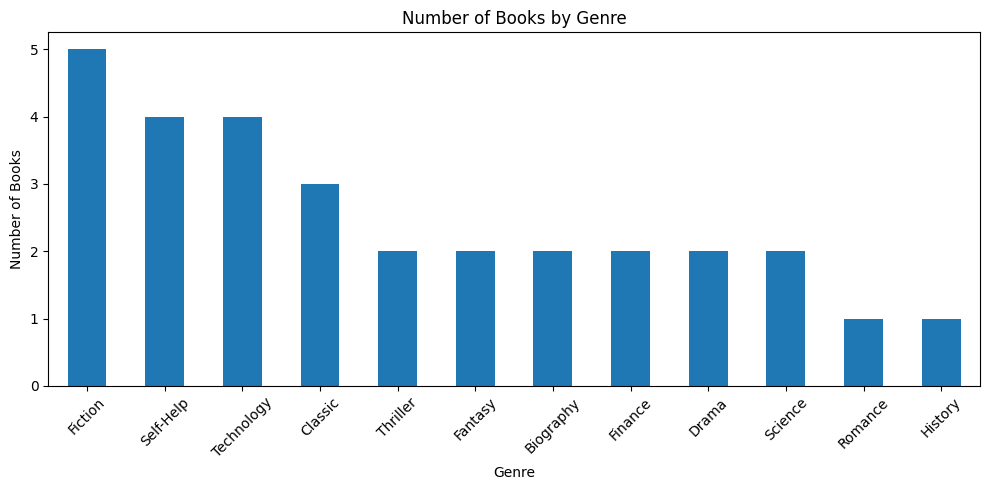

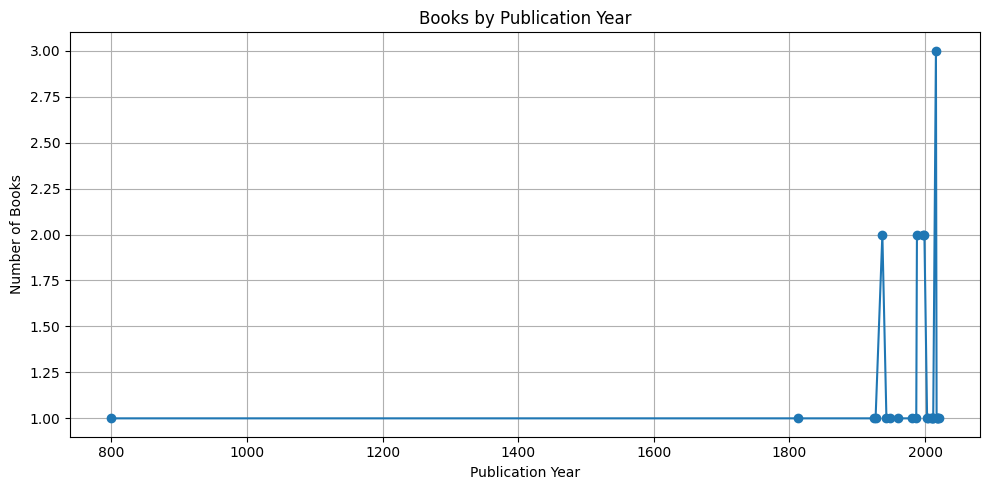


Error while generating visualization: Invalid RGBA argument: None

Visualization operation completed.


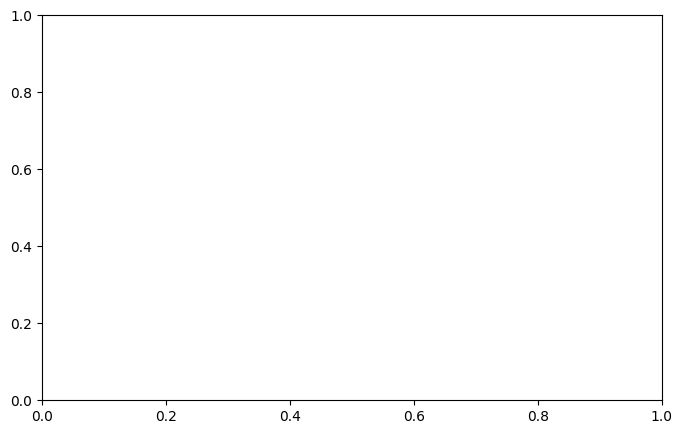

In [37]:
import builtins
_original_df = df.copy(deep=True)
def reset_demo_data():
    global df
    df = _original_df.copy(deep=True)
def run_with_inputs(func, values):
    it = iter(values)
    old = builtins.input
    builtins.input = lambda prompt='': (print(prompt, end=''), str(next(it)))[1]
    try:
        func()
    finally:
        builtins.input = old

reset_demo_data()
generate_visualizations()

### 17. Dashboard — Output


Generating dashboard...


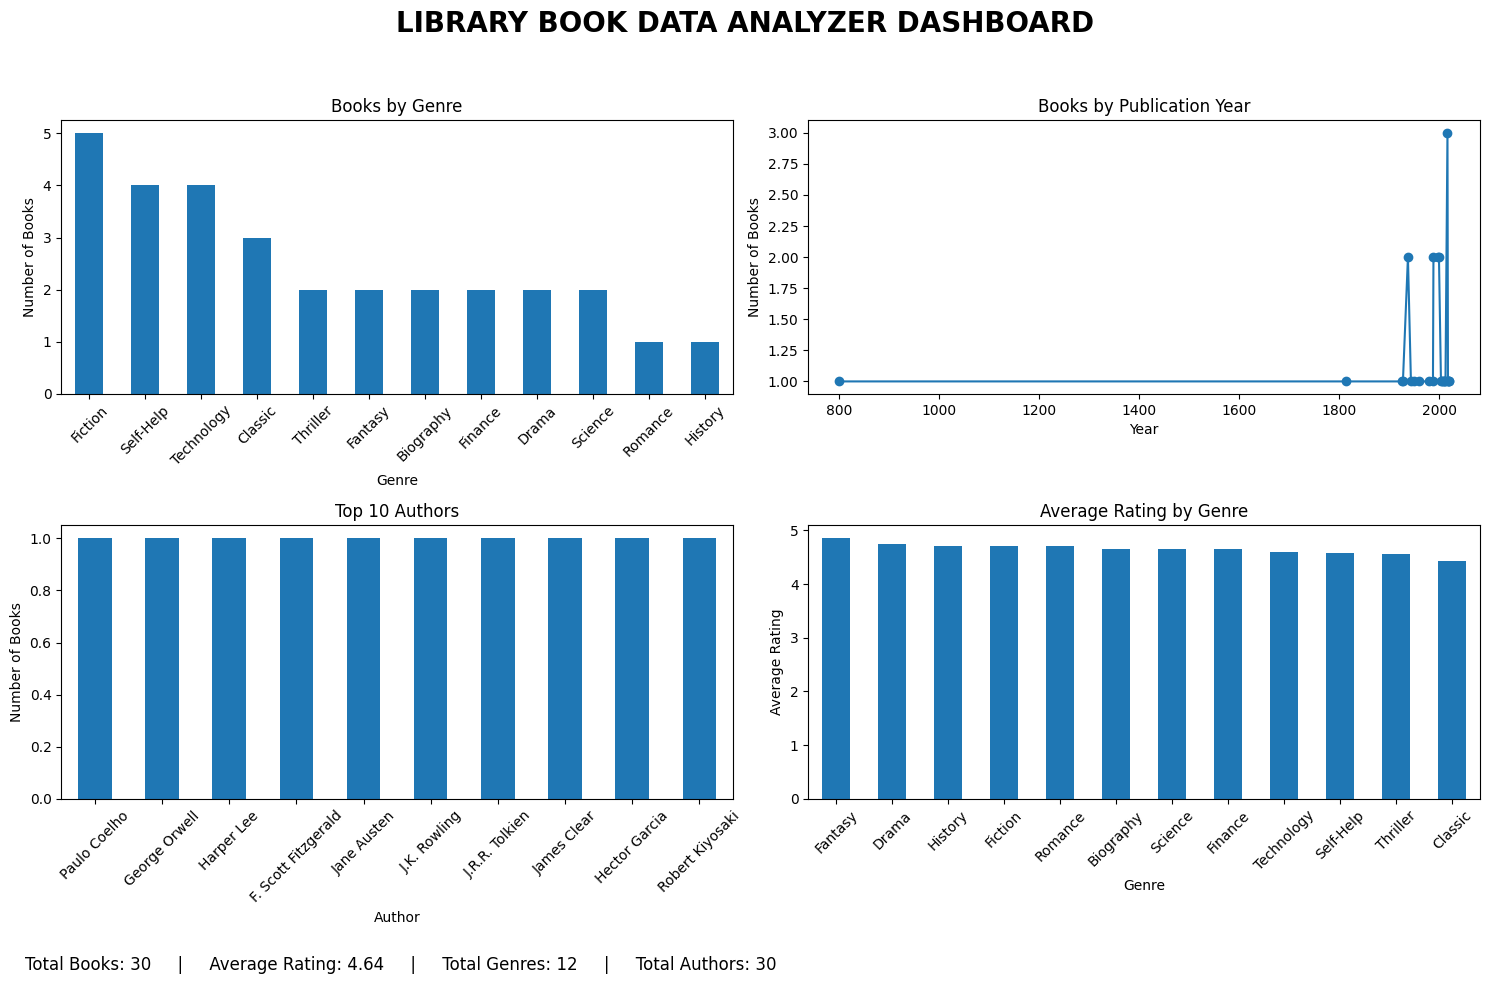


Dashboard saved as 'library_dashboard.png'

Dashboard operation completed.


In [38]:
import builtins
_original_df = df.copy(deep=True)
def reset_demo_data():
    global df
    df = _original_df.copy(deep=True)
def run_with_inputs(func, values):
    it = iter(values)
    old = builtins.input
    builtins.input = lambda prompt='': (print(prompt, end=''), str(next(it)))[1]
    try:
        func()
    finally:
        builtins.input = old

reset_demo_data()
generate_dashboard()